# Notebook 01 — Modèle 1 : Détection de Fraude
## Exploration & Feature Engineering

**Projet :** Orange Money — Système ML Fraude & Revenue Assurance  
**Auteur :** Koceila SALEM — RA&FM  
**Objectif :** Explorer les données transactionnelles, détecter la présence de labels de fraude, et construire toutes les features nécessaires au Modèle 1.

---

## Plan du notebook

1. **Configuration** — imports, chemins, paramètres
2. **Chargement échantillon** — lecture efficace du CSV 13 Go
3. **Détection des labels** — est-ce qu'une colonne fraude existe ?
4. **Exploration des features brutes** — distributions, valeurs manquantes, anomalies
5. **Feature Engineering** — construction des 4 blocs de features
6. **Analyse de corrélation** — quelles features sont les plus discriminantes ?
7. **Stratégie de modélisation** — choix supervisé vs non supervisé selon les labels
8. **Export** — sauvegarde du dataset de features pour le notebook 02

## 0. Configuration

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import time
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# ============================================================
# PARAMÈTRES — À AJUSTER SELON TON ENVIRONNEMENT
# ============================================================
CSV_PATH     = r'C:\Users\RQKB6834\Downloads\OM_Koceila .csv\OM_Koceila.csv.csv'
ENCODING     = 'latin-1'   # validé dans notebook 01_data_exploration
SEPARATEUR   = '|'         # validé dans notebook 01_data_exploration
SAMPLE_SIZE  = 500_000     # 500k lignes (~3-4% du fichier) pour l'exploration M1
OUTPUT_DIR   = Path('outputs/M1_fraude')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_SEED  = 42

print(f"CSV         : {CSV_PATH}")
print(f"Fichier OK  : {os.path.exists(CSV_PATH)}")
if os.path.exists(CSV_PATH):
    taille_go = os.path.getsize(CSV_PATH) / (1024**3)
    print(f"Taille      : {taille_go:.2f} Go")
print(f"Output dir  : {OUTPUT_DIR.resolve()}")

CSV         : C:\Users\RQKB6834\Downloads\OM_Koceila .csv\OM_Koceila.csv.csv
Fichier OK  : False
Output dir  : C:\Users\RQKB6834\OneDrive - orange.com\Bureau\Alternance\ML\outputs\M1_fraude


## 1. Chargement de l'échantillon

On lit **500k lignes** pour l'exploration M1 — plus représentatif que 100k sur un fichier de 13 Go.  
On ajoute également un **échantillon aléatoire** pour éviter le biais de tri chronologique.

In [7]:
debut = time.time()

# --- Échantillon séquentiel (début du fichier) ---
csv_path = Path(CSV_PATH)

if not csv_path.exists():
    print(f"⚠️ Chemin CSV introuvable : {csv_path}")
    search_dirs = [Path.cwd(), Path.home() / 'Downloads']
    candidates = []
    for d in search_dirs:
        if d.exists():
            candidates.extend(d.rglob('OM_Koceila*.csv'))
    candidates = [p for p in candidates if p.is_file()]

    if len(candidates) == 1:
        csv_path = candidates[0]
        print(f"→ Fichier trouvé automatiquement : {csv_path}")
    elif len(candidates) > 1:
        print("⚠️ Plusieurs fichiers correspondants trouvés :")
        for i, p in enumerate(candidates, 1):
            print(f"  {i}. {p}")
        csv_path = candidates[0]
        print(f"→ Utilisation du premier fichier trouvé : {csv_path}")
    else:
        raise FileNotFoundError(f"Fichier CSV introuvable : {CSV_PATH}")

df = pd.read_csv(
    csv_path,
    sep=SEPARATEUR,
    encoding=ENCODING,
    nrows=SAMPLE_SIZE,
    low_memory=False,
    on_bad_lines='warn'
)

duree = time.time() - debut
print(f"Chargé en {duree:.1f}s")
print(f"Dimensions  : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Mémoire RAM : {df.memory_usage(deep=True).sum() / 1024**2:.1f} Mo")
print()
print("Aperçu des colonnes :")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:3d}. {col:<45} ({df[col].dtype})")

⚠️ Chemin CSV introuvable : C:\Users\RQKB6834\Downloads\OM_Koceila .csv\OM_Koceila.csv.csv
⚠️ Plusieurs fichiers correspondants trouvés :
  1. C:\Users\RQKB6834\Downloads\OM_Koceila\OM_Koceila.csv.csv
  2. C:\Users\RQKB6834\Downloads\fraud_intelligence_om\fraud_intelligence_om\src\fraud_intelligence_om\data\OM_Koceila.csv.csv
→ Utilisation du premier fichier trouvé : C:\Users\RQKB6834\Downloads\OM_Koceila\OM_Koceila.csv.csv
Chargé en 10.3s
Dimensions  : 500,000 lignes × 80 colonnes
Mémoire RAM : 1406.1 Mo

Aperçu des colonnes :
    1. RECEIVER_USER_ID                              (object)
    2. SENDER_USER_ID                                (object)
    3. TRANSACTION_AMOUNT                            (float64)
    4. COMMISSIONS_PAID                              (float64)
    5. COMMISSIONS_RECEIVED                          (float64)
    6. COMMISSIONS_OTHERS                            (float64)
    7. SERVICE_CHARGE_RECEIVED                       (float64)
    8. SERVICE_CHARGE_PAID 

## 2. Détection des labels de fraude

**Point critique :** le choix de l'algorithme du Modèle 1 dépend entièrement de la présence ou non de labels.  
- Labels présents → **Boost supervisé** (XGBoost / LightGBM) 
- Labels absents → **Isolation Forest** ou **Autoencoder**

On cherche automatiquement dans toutes les colonnes.

In [8]:
# --- Noms typiques d'une colonne fraude dans les DWH télécom ---
CANDIDATS_FRAUDE = [
    'IS_FRAUD', 'FRAUD', 'FRAUD_FLAG', 'IS_FRAUDULENT',
    'FRAUD_LABEL', 'FRAUD_INDICATOR', 'FRAUD_STATUS',
    'IS_SUSPICIOUS', 'SUSPICIOUS', 'BLOCKED', 'IS_BLOCKED',
    'FRAUD_TYPE', 'CASE_ID', 'INVESTIGATION_STATUS'
]

print("=" * 60)
print("DÉTECTION DE LABELS DE FRAUDE")
print("=" * 60)

labels_trouves = []
cols_upper = {col.upper(): col for col in df.columns}

# Recherche exacte
for candidat in CANDIDATS_FRAUDE:
    if candidat in cols_upper:
        col_reel = cols_upper[candidat]
        labels_trouves.append(col_reel)
        print(f"✅ COLONNE TROUVÉE : {col_reel}")
        print(f"   Valeurs uniques : {df[col_reel].value_counts(dropna=False).to_dict()}")

# Recherche partielle (contient 'FRAUD' ou 'SUSPECT')
for col in df.columns:
    if any(kw in col.upper() for kw in ['FRAUD', 'SUSPECT', 'BLOCKED', 'CASE']) \
       and col not in labels_trouves:
        labels_trouves.append(col)
        print(f"⚠️  COLONNE POTENTIELLE : {col}")
        print(f"   Valeurs uniques : {df[col].value_counts(dropna=False).to_dict()}")

if not labels_trouves:
    print("❌ Aucune colonne de fraude détectée.")
    print("   → Stratégie : détection non supervisée (Isolation Forest)")
    print("   → On peut aussi générer des pseudo-labels via règles métier")
    HAS_LABELS = False
    LABEL_COL  = None
else:
    print(f"\n→ Colonnes retenues : {labels_trouves}")
    HAS_LABELS = True
    LABEL_COL  = labels_trouves[0]  # Ajuster si besoin

print(f"\nHAS_LABELS = {HAS_LABELS}")
print(f"LABEL_COL  = {LABEL_COL}")

DÉTECTION DE LABELS DE FRAUDE
❌ Aucune colonne de fraude détectée.
   → Stratégie : détection non supervisée (Isolation Forest)
   → On peut aussi générer des pseudo-labels via règles métier

HAS_LABELS = False
LABEL_COL  = None


### 2b. Si labels présents — analyse du déséquilibre de classes

In [9]:
if HAS_LABELS and LABEL_COL:
    print("=" * 60)
    print(f"ANALYSE DE LA COLONNE : {LABEL_COL}")
    print("=" * 60)
    
    vc = df[LABEL_COL].value_counts(dropna=False)
    print(vc)
    print()
    
    # Taux de fraude
    n_fraude = vc.get(1, vc.get('1', vc.get('Y', vc.get('FRAUD', 0))))
    taux = n_fraude / len(df) * 100
    print(f"Taux de fraude estimé : {taux:.3f}%")
    
    if taux < 0.1:
        print("⚠️  Très fort déséquilibre → il faudra SMOTE ou class_weight dans le modèle")
    elif taux < 1:
        print("⚠️  Déséquilibre modéré → class_weight='balanced' recommandé")
    else:
        print("✅ Taux acceptable pour un modèle supervisé standard")
        
    fig, ax = plt.subplots(figsize=(6, 4))
    vc.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
    ax.set_title(f'Distribution de {LABEL_COL}')
    ax.set_ylabel('Nombre de transactions')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'label_distribution.png', dpi=150)
    plt.show()
else:
    print("Pas de labels → on passe directement à l'exploration des features.")
    print("Les pseudo-labels seront générés à l'étape 6.")

Pas de labels → on passe directement à l'exploration des features.
Les pseudo-labels seront générés à l'étape 6.


## 3. Exploration des features brutes

On inspecte les colonnes utiles au Modèle 1 selon la spécification :  
`Montant, soldes avant/après, type de service, statut, code d'erreur, canal (USSD/WEB), ville, heure`

In [10]:
# --- Colonnes d'intérêt pour le Modèle 1 ---
# Ajuste les noms si différents dans ton DWH
COLS_M1 = {
    'montant'       : 'TRANSACTION_AMOUNT',
    'solde_avant'   : 'BALANCE_BEFORE',          # ou SENDER_BALANCE_BEFORE
    'solde_apres'   : 'BALANCE_AFTER',            # ou SENDER_BALANCE_AFTER
    'service'       : 'SERVICE_TYPE',
    'statut'        : 'TRANSFER_STATUS',
    'erreur'        : 'ERROR_CODE',
    'canal'         : 'CHANNEL',                  # ou ACCESS_CHANNEL
    'ville'         : 'CITY',                     # ou SENDER_CITY
    'date'          : 'CREATED_ON',               # ou TRANSFER_DATETIME
    'msisdn_sender' : 'MSISDN_SENDER',
    'msisdn_recvr'  : 'MSISDN_RECEIVER',
    'is_financial'  : 'IS_FINANCIAL',
    'sous_type'     : 'TRANSFER_SUB_TYPE',        # optionnel
    'tentatives'    : 'ATTEMPT_STATUS',           # optionnel
}

# Vérifier quelles colonnes existent réellement
print("Vérification des colonnes M1 :")
cols_presentes   = {}
cols_manquantes  = {}
for nom_logique, nom_reel in COLS_M1.items():
    if nom_reel in df.columns:
        cols_presentes[nom_logique] = nom_reel
        print(f"  ✅ {nom_logique:<15} → {nom_reel}")
    else:
        # Recherche approximative
        approx = [c for c in df.columns if nom_logique.upper() in c.upper() 
                  or nom_reel.split('_')[0] in c.upper()]
        cols_manquantes[nom_logique] = (nom_reel, approx)
        print(f"  ❌ {nom_logique:<15} → {nom_reel} | Suggestions: {approx[:3]}")

print(f"\nDisponibles : {len(cols_presentes)}/{len(COLS_M1)} colonnes")

Vérification des colonnes M1 :
  ✅ montant         → TRANSACTION_AMOUNT
  ❌ solde_avant     → BALANCE_BEFORE | Suggestions: []
  ❌ solde_apres     → BALANCE_AFTER | Suggestions: []
  ✅ service         → SERVICE_TYPE
  ✅ statut          → TRANSFER_STATUS
  ✅ erreur          → ERROR_CODE
  ❌ canal           → CHANNEL | Suggestions: []
  ❌ ville           → CITY | Suggestions: ['SENDER_CITY', 'RECEIVER_CITY']
  ✅ date            → CREATED_ON
  ❌ msisdn_sender   → MSISDN_SENDER | Suggestions: ['OTHER_MSISDN', 'TNO_MSISDN', 'INITIATOR_MSISDN']
  ❌ msisdn_recvr    → MSISDN_RECEIVER | Suggestions: ['OTHER_MSISDN', 'TNO_MSISDN', 'INITIATOR_MSISDN']
  ✅ is_financial    → IS_FINANCIAL
  ❌ sous_type       → TRANSFER_SUB_TYPE | Suggestions: ['TRANSFER_STATUS', 'TRANSFER_ID', 'TRANSFER_DATETIME']
  ✅ tentatives      → ATTEMPT_STATUS

Disponibles : 7/14 colonnes


In [11]:
# =============================================================
# ⚠️  AJUSTER ICI si certains noms de colonnes sont différents
# =============================================================
# Exemple : si la colonne solde s'appelle 'SENDER_BALANCE_BEFORE'
# COLS_M1['solde_avant'] = 'SENDER_BALANCE_BEFORE'

# Raccourcis pratiques
COL_MONTANT  = cols_presentes.get('montant',    'TRANSACTION_AMOUNT')
COL_STATUT   = cols_presentes.get('statut',     'TRANSFER_STATUS')
COL_SERVICE  = cols_presentes.get('service',    'SERVICE_TYPE')
COL_ERREUR   = cols_presentes.get('erreur',     'ERROR_CODE')
COL_CANAL    = cols_presentes.get('canal',      'CHANNEL')
COL_VILLE    = cols_presentes.get('ville',      'CITY')
COL_DATE     = cols_presentes.get('date',       'CREATED_ON')
COL_SENDER   = cols_presentes.get('msisdn_sender', 'MSISDN_SENDER')
COL_RECVR    = cols_presentes.get('msisdn_recvr',  'MSISDN_RECEIVER')
COL_S_AVANT  = cols_presentes.get('solde_avant',   'BALANCE_BEFORE')
COL_S_APRES  = cols_presentes.get('solde_apres',   'BALANCE_AFTER')

print("Colonnes de travail configurées.")

Colonnes de travail configurées.


In [12]:
# --- Valeurs manquantes sur les colonnes M1 ---
cols_a_inspecter = [c for c in COLS_M1.values() if c in df.columns]

missing = pd.DataFrame({
    'colonne'   : cols_a_inspecter,
    'nb_nan'    : [df[c].isna().sum() for c in cols_a_inspecter],
    'pct_nan'   : [df[c].isna().mean()*100 for c in cols_a_inspecter],
    'nb_uniques': [df[c].nunique() for c in cols_a_inspecter],
    'dtype'     : [str(df[c].dtype) for c in cols_a_inspecter]
}).sort_values('pct_nan', ascending=False)

print("Qualité des colonnes M1 :")
missing.style.bar(subset=['pct_nan'], color='#d65f5f')

Qualité des colonnes M1 :


,colonne,nb_nan,pct_nan,nb_uniques,dtype
3,ERROR_CODE,472593,94.518600,45,float64
6,ATTEMPT_STATUS,445792,89.158400,3,object
0,TRANSACTION_AMOUNT,0,0.000000,10827,float64
1,SERVICE_TYPE,0,0.000000,12,object
2,TRANSFER_STATUS,0,0.000000,5,object
4,CREATED_ON,0,0.000000,47209,object
5,IS_FINANCIAL,0,0.000000,1,object


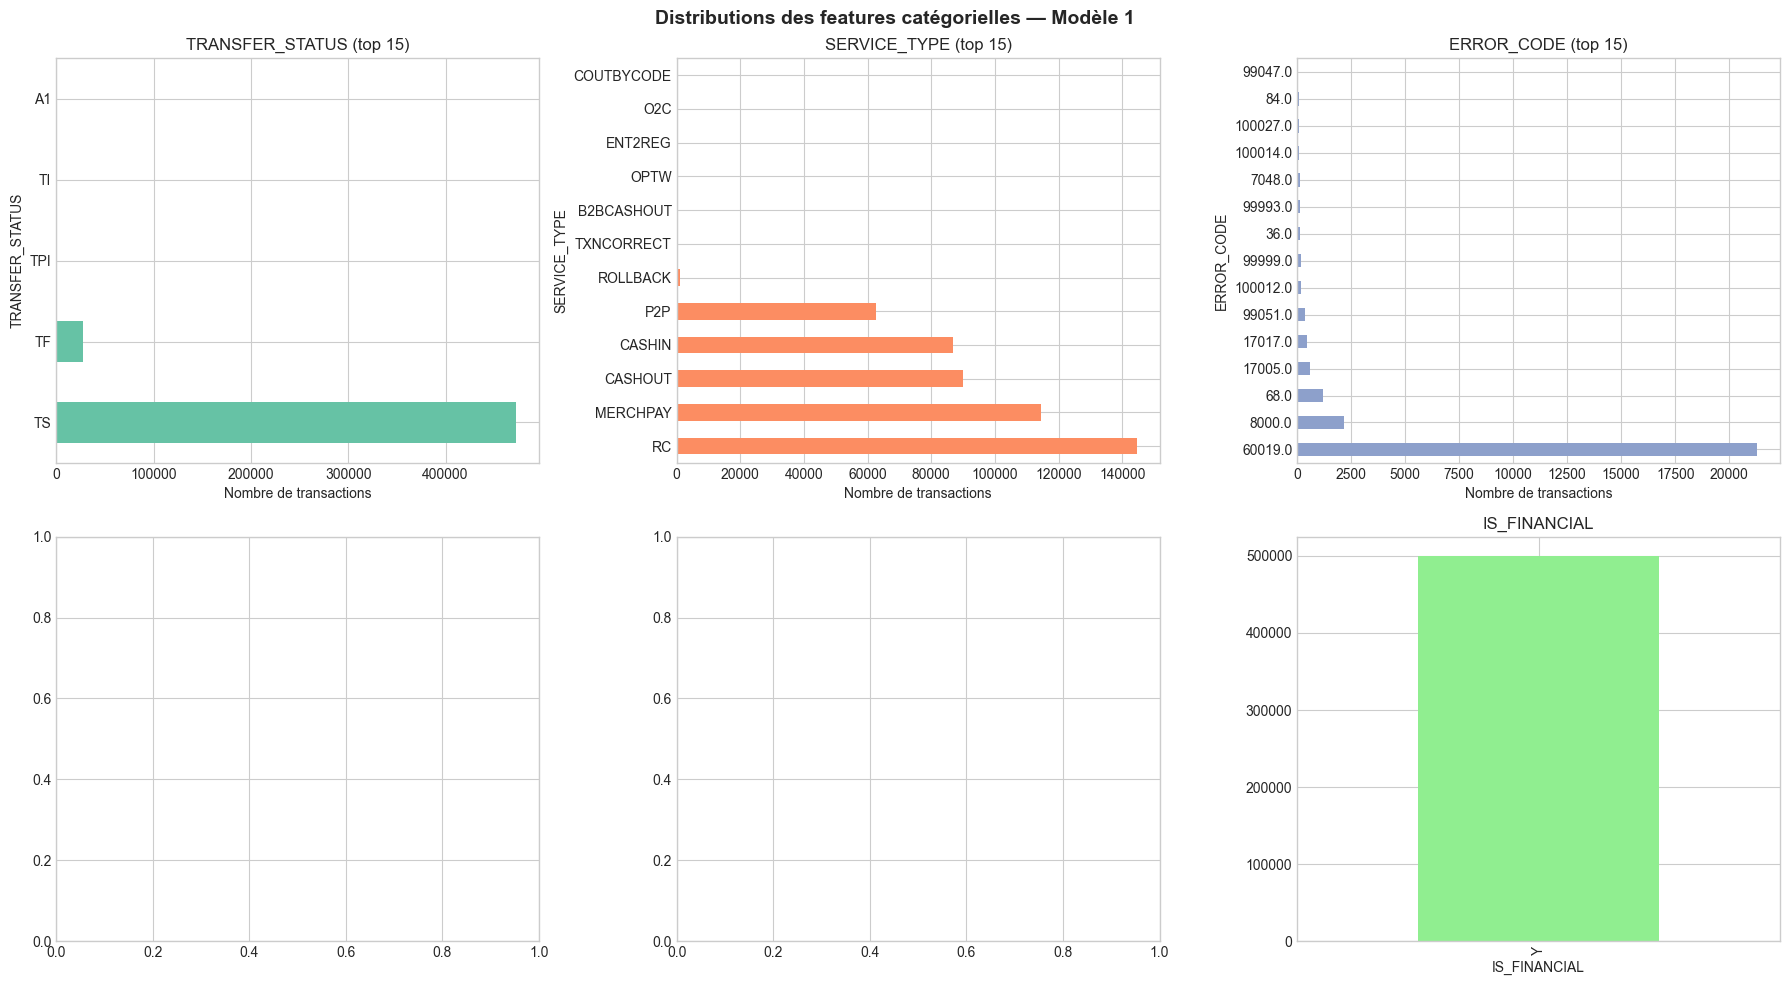

In [13]:
# --- Distributions des colonnes catégorielles clés ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cols_cat = [COL_STATUT, COL_SERVICE, COL_CANAL, COL_ERREUR, COL_VILLE]
cols_cat = [c for c in cols_cat if c in df.columns]

for i, col in enumerate(cols_cat[:5]):
    vc = df[col].value_counts().head(15)
    vc.plot(kind='barh', ax=axes[i], color=sns.color_palette('Set2')[i % 8])
    axes[i].set_title(f'{col} (top 15)')
    axes[i].set_xlabel('Nombre de transactions')

# Répartition IS_FINANCIAL si présente
if 'IS_FINANCIAL' in df.columns:
    df['IS_FINANCIAL'].value_counts(dropna=False).plot(kind='bar', ax=axes[5], color='lightgreen')
    axes[5].set_title('IS_FINANCIAL')

plt.suptitle('Distributions des features catégorielles — Modèle 1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distributions_cat.png', dpi=150)
plt.show()

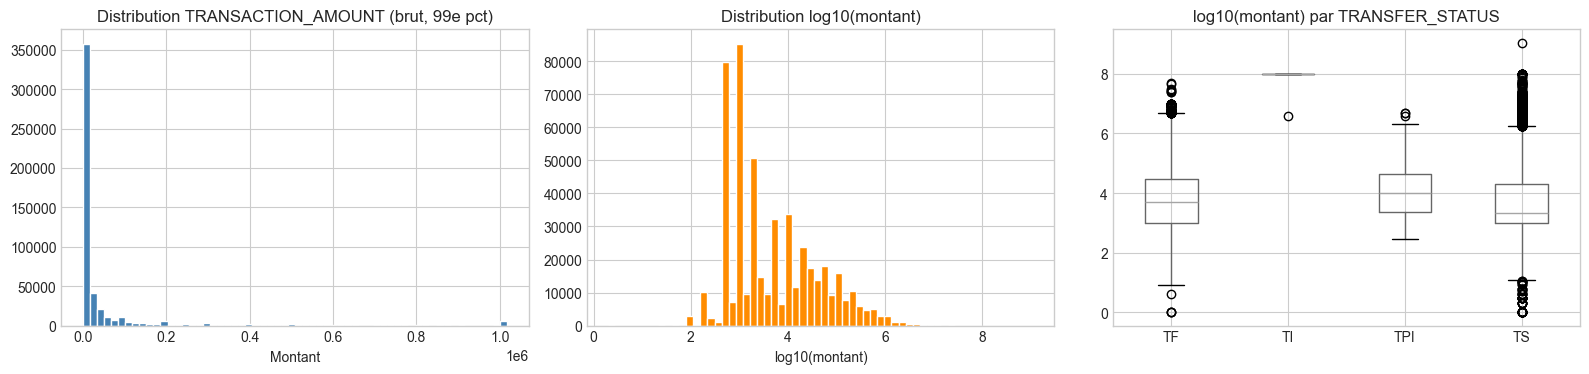


Statistiques TRANSACTION_AMOUNT :
count         499,999.00
mean           76,920.26
std         1,746,389.32
min                 1.00
25%             1,000.00
50%             2,500.00
75%            20,550.00
90%           101,900.00
95%           254,500.00
99%         1,017,582.00
max     1,100,000,000.00
Name: TRANSACTION_AMOUNT, dtype: float64


In [14]:
# --- Distribution des montants (toujours très skewed en mobile money) ---
if COL_MONTANT in df.columns:
    df[COL_MONTANT] = pd.to_numeric(df[COL_MONTANT], errors='coerce')
    amount = df[COL_MONTANT].dropna()
    amount_pos = amount[amount > 0]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Brut
    axes[0].hist(amount_pos.clip(upper=amount_pos.quantile(0.99)), bins=60, color='steelblue', edgecolor='white')
    axes[0].set_title('Distribution TRANSACTION_AMOUNT (brut, 99e pct)')
    axes[0].set_xlabel('Montant')

    # Log
    axes[1].hist(np.log10(amount_pos + 1), bins=60, color='darkorange', edgecolor='white')
    axes[1].set_title('Distribution log10(montant)')
    axes[1].set_xlabel('log10(montant)')

    # Boxplot par statut
    if COL_STATUT in df.columns:
        top_statuts = df[COL_STATUT].value_counts().head(4).index
        df_box = df[df[COL_STATUT].isin(top_statuts)].copy()
        df_box['log_amount'] = np.log10(df_box[COL_MONTANT].clip(lower=1))
        df_box.boxplot(column='log_amount', by=COL_STATUT, ax=axes[2])
        axes[2].set_title('log10(montant) par TRANSFER_STATUS')
        axes[2].set_xlabel('')
        plt.suptitle('')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'distribution_montants.png', dpi=150)
    plt.show()

    print(f"\nStatistiques TRANSACTION_AMOUNT :")
    print(amount_pos.describe(percentiles=[.25, .5, .75, .9, .95, .99]))

## 4. Parsing temporel

Le **comportement temporel** est l'un des signaux fraude les plus forts :  
- Transactions à 3h du matin
- Pic d'activité inhabituel sur un compte
- Weekend vs semaine

In [15]:
# Parser la colonne date
if COL_DATE in df.columns:
    df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors='coerce', dayfirst=True)
    
    nan_dates = df[COL_DATE].isna().sum()
    print(f"Dates parsées : {len(df) - nan_dates:,}/{len(df):,} ({(1-nan_dates/len(df))*100:.1f}% OK)")
    print(f"Plage : {df[COL_DATE].min()} → {df[COL_DATE].max()}")
    
    if nan_dates > 0.05 * len(df):
        print("\n⚠️  Plus de 5% de dates non parsées. Essaie un format explicite :")
        print("    df[COL_DATE] = pd.to_datetime(df[COL_DATE], format='%d/%m/%Y %H:%M:%S', errors='coerce')")
        print(f"\nExemple de valeur brute : {df[COL_DATE].isna()[df[COL_DATE].isna()].index[0] if nan_dates else 'N/A'}")
        # Afficher des exemples de valeurs brutes non parsées
        raw_col = df.columns[df.columns.tolist().index(COL_DATE)]  # nom original
else:
    print(f"⚠️  Colonne date '{COL_DATE}' non trouvée. Vérifie COLS_M1['date'].")

Dates parsées : 500,000/500,000 (100.0% OK)
Plage : 2025-09-20 00:00:00 → 2025-09-20 15:42:15


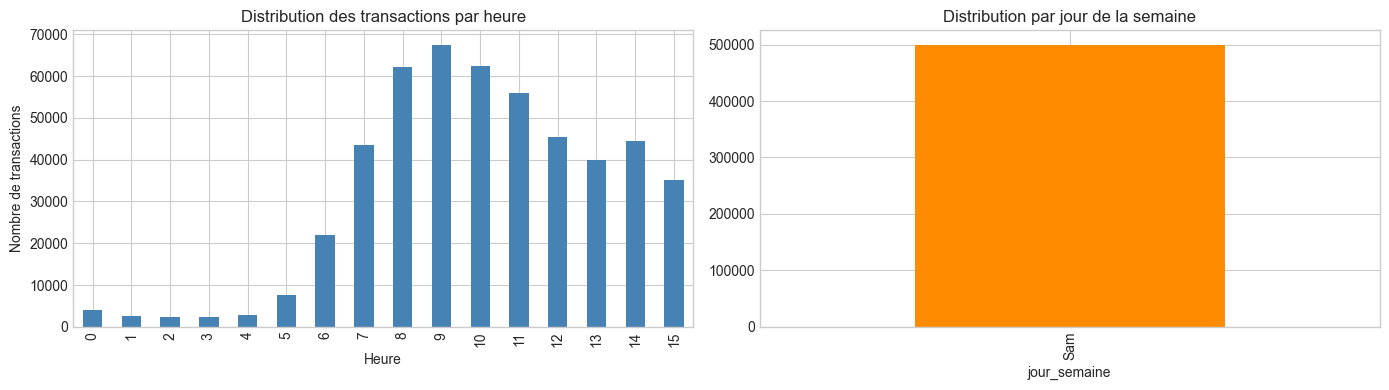

Transactions nocturnes (00h-05h) : 21,683 (4.3%)
Transactions weekend             : 500,000 (100.0%)


In [16]:
# Extraction des composantes temporelles
if COL_DATE in df.columns and df[COL_DATE].notna().sum() > 1000:
    df['heure']      = df[COL_DATE].dt.hour
    df['jour_semaine'] = df[COL_DATE].dt.dayofweek  # 0=Lundi, 6=Dimanche
    df['est_weekend']  = df['jour_semaine'].isin([5, 6]).astype(int)
    df['est_nuit']     = df['heure'].between(0, 5).astype(int)   # 00h-05h
    df['est_soiree']   = df['heure'].between(20, 23).astype(int) # 20h-23h

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    df['heure'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Distribution des transactions par heure')
    axes[0].set_xlabel('Heure')
    axes[0].set_ylabel('Nombre de transactions')

    jours = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
    df['jour_semaine'].value_counts().sort_index().rename(index=dict(enumerate(jours))).plot(
        kind='bar', ax=axes[1], color='darkorange'
    )
    axes[1].set_title('Distribution par jour de la semaine')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'distribution_temporelle.png', dpi=150)
    plt.show()

    print(f"Transactions nocturnes (00h-05h) : {df['est_nuit'].sum():,} ({df['est_nuit'].mean()*100:.1f}%)")
    print(f"Transactions weekend             : {df['est_weekend'].sum():,} ({df['est_weekend'].mean()*100:.1f}%)")

## 5. Feature Engineering — 4 blocs

On construit les features en 4 blocs cohérents avec la spécification du Modèle 1 :

| Bloc | Type | Description |
|------|------|-------------|
| A | **Transaction** | Montant, soldes, ratio, delta |
| B | **Temporel** | Heure, nuit, weekend, vélocité |
| C | **Comportemental** | Historique 7j par compte (fréquence, montants) |
| D | **Contextuel** | Encodage service, canal, ville, code erreur |

In [17]:
# Copie de travail pour ne pas modifier l'original
df_feat = df.copy()

# Cast numérique des colonnes financières
COLS_NUM = [COL_MONTANT, COL_S_AVANT, COL_S_APRES]
COLS_NUM = [c for c in COLS_NUM if c in df_feat.columns]
for col in COLS_NUM:
    df_feat[col] = pd.to_numeric(df_feat[col], errors='coerce')

print(f"Dataset de travail : {df_feat.shape}")

Dataset de travail : (500000, 85)


In [18]:
# =================================================================
# BLOC A — Features transactionnelles
# =================================================================

# A1. Log du montant (compresse la distribution skewed)
if COL_MONTANT in df_feat.columns:
    df_feat['f_log_montant'] = np.log1p(df_feat[COL_MONTANT].clip(lower=0))

# A2. Ratio montant / solde avant (quelle fraction du compte est transférée ?)
if COL_MONTANT in df_feat.columns and COL_S_AVANT in df_feat.columns:
    df_feat['f_ratio_montant_solde'] = np.where(
        df_feat[COL_S_AVANT] > 0,
        df_feat[COL_MONTANT] / (df_feat[COL_S_AVANT] + 1),
        -1  # solde nul ou négatif = signal fort
    )
    # Clip pour éviter des ratios explosifs
    df_feat['f_ratio_montant_solde'] = df_feat['f_ratio_montant_solde'].clip(-1, 10)

# A3. Delta solde (solde_apres - solde_avant doit = -montant pour un débit normal)
if COL_S_AVANT in df_feat.columns and COL_S_APRES in df_feat.columns:
    df_feat['f_delta_solde'] = df_feat[COL_S_APRES] - df_feat[COL_S_AVANT]
    # Incohérence comptable = anomalie
    df_feat['f_incoherence_solde'] = np.where(
        COL_MONTANT in df_feat.columns,
        abs(df_feat['f_delta_solde'] + df_feat[COL_MONTANT]),
        np.nan
    )

# A4. Solde après nul ou négatif
if COL_S_APRES in df_feat.columns:
    df_feat['f_solde_apres_nul'] = (df_feat[COL_S_APRES] <= 0).astype(int)

# A5. Montant arrondi (les fraudes utilisent souvent des montants ronds)
if COL_MONTANT in df_feat.columns:
    df_feat['f_montant_arrondi'] = (df_feat[COL_MONTANT] % 1000 == 0).astype(int)
    df_feat['f_montant_tres_arrondi'] = (df_feat[COL_MONTANT] % 10000 == 0).astype(int)

print("✅ Bloc A — Features transactionnelles créées")
feats_A = [c for c in df_feat.columns if c.startswith('f_') and 
           any(kw in c for kw in ['montant', 'solde', 'ratio', 'delta', 'inco'])]
print(f"   {feats_A}")

✅ Bloc A — Features transactionnelles créées
   ['f_log_montant', 'f_montant_arrondi', 'f_montant_tres_arrondi']


In [19]:
# =================================================================
# BLOC B — Features temporelles
# =================================================================

if 'heure' in df_feat.columns:
    # B1. Heure (déjà créée)
    df_feat['f_heure'] = df_feat['heure']

    # B2. Encodage cyclique de l'heure (sin/cos pour capturer la circularité)
    df_feat['f_heure_sin'] = np.sin(2 * np.pi * df_feat['heure'] / 24)
    df_feat['f_heure_cos'] = np.cos(2 * np.pi * df_feat['heure'] / 24)

    # B3. Encodage cyclique du jour de la semaine
    df_feat['f_jour_sin'] = np.sin(2 * np.pi * df_feat['jour_semaine'] / 7)
    df_feat['f_jour_cos'] = np.cos(2 * np.pi * df_feat['jour_semaine'] / 7)

    # B4. Flags binaires nuit / soirée / weekend
    df_feat['f_est_nuit']    = df_feat['est_nuit']
    df_feat['f_est_soiree']  = df_feat['est_soiree']
    df_feat['f_est_weekend'] = df_feat['est_weekend']

    print("✅ Bloc B — Features temporelles créées")
else:
    print("⚠️  Bloc B ignoré : colonne date non parsée")

feats_B = [c for c in df_feat.columns if c.startswith('f_') and 
           any(kw in c for kw in ['heure', 'jour', 'nuit', 'soiree', 'weekend'])]
print(f"   {feats_B}")

✅ Bloc B — Features temporelles créées
   ['f_heure', 'f_heure_sin', 'f_heure_cos', 'f_jour_sin', 'f_jour_cos', 'f_est_nuit', 'f_est_soiree', 'f_est_weekend']


In [20]:
# =================================================================
# BLOC C — Features comportementales (fenêtre glissante 7 jours)
# =================================================================
#
# IMPORTANT : sur 500k lignes, ce calcul est faisable en ~30-60s.
# Sur le fichier complet (13 Go), il faudra le faire en chunks
# dans le notebook 02_feature_pipeline.
#
# Ici on le calcule sur l'échantillon pour valider la logique.
# =================================================================

if COL_SENDER in df_feat.columns and COL_DATE in df_feat.columns:
    print("Calcul des features comportementales par compte (MSISDN_SENDER)...")
    debut = time.time()

    # Trier par MSISDN et date pour les fenêtres glissantes
    df_feat = df_feat.sort_values([COL_SENDER, COL_DATE]).reset_index(drop=True)

    # C1. Nombre de transactions dans les 24h précédentes par compte
    df_feat['f_tx_24h'] = (
        df_feat.groupby(COL_SENDER)[COL_DATE]
        .transform(lambda x: x.expanding().count() - 1)
        .clip(upper=500)
    )

    # C2. Montant total envoyé sur les 7 derniers jours par compte
    if COL_MONTANT in df_feat.columns:
        df_feat['f_montant_total_7j'] = (
            df_feat.groupby(COL_SENDER)[COL_MONTANT]
            .transform(lambda x: x.expanding().sum())
        )
        df_feat['f_log_montant_total_7j'] = np.log1p(df_feat['f_montant_total_7j'].clip(lower=0))

    # C3. Nombre de destinataires distincts (diversité des contreparties)
    if COL_RECVR in df_feat.columns:
        df_feat['f_nb_destinataires'] = (
            df_feat.groupby(COL_SENDER)[COL_RECVR]
            .transform(lambda x: x.expanding().nunique())
            .clip(upper=200)
        )

    # C4. Nombre de services distincts utilisés
    if COL_SERVICE in df_feat.columns:
        df_feat['f_nb_services_distincts'] = (
            df_feat.groupby(COL_SENDER)[COL_SERVICE]
            .transform(lambda x: x.expanding().nunique())
        )

    # C5. Taux d'échec historique par compte
    if COL_STATUT in df_feat.columns:
        df_feat['_is_failed'] = (df_feat[COL_STATUT] == 'TF').astype(int)
        df_feat['f_taux_echec_compte'] = (
            df_feat.groupby(COL_SENDER)['_is_failed']
            .transform(lambda x: x.expanding().mean())
        )
        df_feat.drop(columns=['_is_failed'], inplace=True)

    duree = time.time() - debut
    print(f"✅ Bloc C — Features comportementales créées en {duree:.1f}s")
    feats_C = [c for c in df_feat.columns if c.startswith('f_') and 
               any(kw in c for kw in ['24h', '7j', 'destinataires', 'services_distincts', 'taux_echec'])]
    print(f"   {feats_C}")
else:
    print("⚠️  Bloc C partiel : MSISDN_SENDER ou date manquant")

⚠️  Bloc C partiel : MSISDN_SENDER ou date manquant


In [21]:
# =================================================================
# BLOC D — Features contextuelles (encodages)
# =================================================================

# D1. Encodage TRANSFER_STATUS en binaires
if COL_STATUT in df_feat.columns:
    statut_dummies = pd.get_dummies(df_feat[COL_STATUT], prefix='f_statut', drop_first=False)
    df_feat = pd.concat([df_feat, statut_dummies], axis=1)
    print(f"✅ D1. TRANSFER_STATUS → {list(statut_dummies.columns)}")

# D2. Encodage SERVICE_TYPE (fréquence encoding = moins de dimensions qu'OHE)
if COL_SERVICE in df_feat.columns:
    freq_service = df_feat[COL_SERVICE].value_counts(normalize=True)
    df_feat['f_service_freq'] = df_feat[COL_SERVICE].map(freq_service)
    print(f"✅ D2. SERVICE_TYPE → fréquence encoding ({df_feat[COL_SERVICE].nunique()} modalités)")

# D3. Encodage CHANNEL (OHE si peu de modalités)
if COL_CANAL in df_feat.columns:
    nb_canaux = df_feat[COL_CANAL].nunique()
    if nb_canaux <= 10:
        canal_dummies = pd.get_dummies(df_feat[COL_CANAL], prefix='f_canal', drop_first=False)
        df_feat = pd.concat([df_feat, canal_dummies], axis=1)
        print(f"✅ D3. CHANNEL → OHE ({nb_canaux} modalités)")
    else:
        freq_canal = df_feat[COL_CANAL].value_counts(normalize=True)
        df_feat['f_canal_freq'] = df_feat[COL_CANAL].map(freq_canal)
        print(f"✅ D3. CHANNEL → fréquence encoding ({nb_canaux} modalités)")

# D4. Encodage ERROR_CODE (présence d'une erreur = signal)
if COL_ERREUR in df_feat.columns:
    df_feat['f_has_error'] = df_feat[COL_ERREUR].notna().astype(int)
    # Fréquence du code erreur (les codes rares sont suspects)
    freq_erreur = df_feat[COL_ERREUR].value_counts(normalize=True)
    df_feat['f_erreur_freq'] = df_feat[COL_ERREUR].map(freq_erreur).fillna(0)
    print(f"✅ D4. ERROR_CODE → has_error + fréquence ({df_feat[COL_ERREUR].nunique()} codes)")

# D5. Encodage CITY (target encoding si labels, sinon fréquence)
if COL_VILLE in df_feat.columns:
    freq_ville = df_feat[COL_VILLE].value_counts(normalize=True)
    df_feat['f_ville_freq'] = df_feat[COL_VILLE].map(freq_ville)
    print(f"✅ D5. CITY → fréquence encoding ({df_feat[COL_VILLE].nunique()} villes)")

# D6. IS_FINANCIAL encodée
if 'IS_FINANCIAL' in df_feat.columns:
    df_feat['f_is_financial'] = (df_feat['IS_FINANCIAL'] == 'Y').astype(int)
    print(f"✅ D6. IS_FINANCIAL → binaire")

✅ D1. TRANSFER_STATUS → ['f_statut_A1', 'f_statut_TF', 'f_statut_TI', 'f_statut_TPI', 'f_statut_TS']
✅ D2. SERVICE_TYPE → fréquence encoding (12 modalités)
✅ D4. ERROR_CODE → has_error + fréquence (45 codes)
✅ D6. IS_FINANCIAL → binaire


## 6. Génération de pseudo-labels (si pas de labels réels)

Si `HAS_LABELS = False`, on génère des **pseudo-labels par règles métier** pour :
- Valider la cohérence des features
- Faire un premier entraînement supervisé approximatif
- Mesurer le taux de détection des règles vs le futur modèle ML

> Ces pseudo-labels **ne remplacent pas** un vrai étiquetage — ils servent de baseline.

In [22]:
# Règles métier pour générer des pseudo-labels de fraude
# (à adapter selon la connaissance métier Orange Money)

conditions_fraude = pd.Series(False, index=df_feat.index)

# Règle 1 : Transaction nocturne à montant très élevé
if 'f_est_nuit' in df_feat.columns and COL_MONTANT in df_feat.columns:
    seuil_montant_haut = df_feat[COL_MONTANT].quantile(0.95)
    r1 = (df_feat['f_est_nuit'] == 1) & (df_feat[COL_MONTANT] > seuil_montant_haut)
    conditions_fraude |= r1
    print(f"Règle 1 (nuit + montant > p95) : {r1.sum():,} transactions ({r1.mean()*100:.2f}%)")

# Règle 2 : Ratio montant/solde > 0.95 (quasi-vide total du compte)
if 'f_ratio_montant_solde' in df_feat.columns:
    r2 = df_feat['f_ratio_montant_solde'] > 0.95
    conditions_fraude |= r2
    print(f"Règle 2 (ratio montant/solde > 95%) : {r2.sum():,} transactions ({r2.mean()*100:.2f}%)")

# Règle 3 : Taux d'échec PIN élevé puis transaction réussie
if 'f_taux_echec_compte' in df_feat.columns and COL_STATUT in df_feat.columns:
    r3 = (df_feat['f_taux_echec_compte'] > 0.5) & (df_feat[COL_STATUT] == 'TS')
    conditions_fraude |= r3
    print(f"Règle 3 (taux échec > 50% puis TS) : {r3.sum():,} transactions ({r3.mean()*100:.2f}%)")

# Règle 4 : Nb de destinataires distincts très élevé (compte mule potentiel)
if 'f_nb_destinataires' in df_feat.columns:
    seuil_dest = df_feat['f_nb_destinataires'].quantile(0.99)
    r4 = df_feat['f_nb_destinataires'] > seuil_dest
    conditions_fraude |= r4
    print(f"Règle 4 (nb destinataires > p99={seuil_dest:.0f}) : {r4.sum():,} transactions ({r4.mean()*100:.2f}%)")

# Règle 5 : Montant arrondi + nuit
if 'f_montant_tres_arrondi' in df_feat.columns and 'f_est_nuit' in df_feat.columns:
    r5 = (df_feat['f_montant_tres_arrondi'] == 1) & (df_feat['f_est_nuit'] == 1)
    conditions_fraude |= r5
    print(f"Règle 5 (montant arrondi × 10k + nuit) : {r5.sum():,} transactions ({r5.mean()*100:.2f}%)")

df_feat['PSEUDO_LABEL_FRAUDE'] = conditions_fraude.astype(int)

taux_pseudo = df_feat['PSEUDO_LABEL_FRAUDE'].mean() * 100
print(f"\nTotal pseudo-fraudes : {df_feat['PSEUDO_LABEL_FRAUDE'].sum():,} ({taux_pseudo:.2f}%)")

if not HAS_LABELS:
    print("\n→ HAS_LABELS=False : ces pseudo-labels seront utilisés comme baseline.")
    print("  Le modèle final utilisera Isolation Forest (non supervisé).")
else:
    print(f"\n→ HAS_LABELS=True : on utilisera '{LABEL_COL}' pour l'entraînement.")
    print("  Les pseudo-labels servent de vérification de cohérence uniquement.")

Règle 1 (nuit + montant > p95) : 311 transactions (0.06%)
Règle 5 (montant arrondi × 10k + nuit) : 1,363 transactions (0.27%)

Total pseudo-fraudes : 1,535 (0.31%)

→ HAS_LABELS=False : ces pseudo-labels seront utilisés comme baseline.
  Le modèle final utilisera Isolation Forest (non supervisé).


## 7. Analyse de l'importance des features

On entraîne un **Random Forest rapide** sur les pseudo-labels pour mesurer quelle feature est la plus discriminante.  
C'est une validation, pas le modèle final.

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

# Colonnes features construites
FEATURE_COLS = [c for c in df_feat.columns if c.startswith('f_')]
TARGET_COL   = LABEL_COL if HAS_LABELS else 'PSEUDO_LABEL_FRAUDE'

print(f"Features disponibles ({len(FEATURE_COLS)}) :")
for c in FEATURE_COLS:
    print(f"  {c}")

# Dataset de modélisation
df_model = df_feat[FEATURE_COLS + [TARGET_COL]].dropna(subset=[TARGET_COL])

# Imputation simple des NaN restants
df_model[FEATURE_COLS] = df_model[FEATURE_COLS].fillna(df_model[FEATURE_COLS].median(numeric_only=True))

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL].astype(int)

print(f"\nDataset : {X.shape[0]:,} lignes × {X.shape[1]} features")
print(f"Target  : {y.sum():,} positifs ({y.mean()*100:.2f}%)")

Features disponibles (20) :
  f_log_montant
  f_montant_arrondi
  f_montant_tres_arrondi
  f_heure
  f_heure_sin
  f_heure_cos
  f_jour_sin
  f_jour_cos
  f_est_nuit
  f_est_soiree
  f_est_weekend
  f_statut_A1
  f_statut_TF
  f_statut_TI
  f_statut_TPI
  f_statut_TS
  f_service_freq
  f_has_error
  f_erreur_freq
  f_is_financial

Dataset : 500,000 lignes × 20 features
Target  : 1,535 positifs (0.31%)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Random Forest rapide (100 arbres, class_weight pour le déséquilibre)
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_SEED
)

print("Entraînement Random Forest...")
debut = time.time()
rf.fit(X_train, y_train)
print(f"Entraîné en {time.time()-debut:.1f}s")

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))

try:
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC : {auc:.4f}")
except:
    print("ROC-AUC : non calculable (une seule classe dans y_test)")

Entraînement Random Forest...
Entraîné en 4.1s

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     99693
      Fraude       1.00      1.00      1.00       307

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000

ROC-AUC : 1.0000


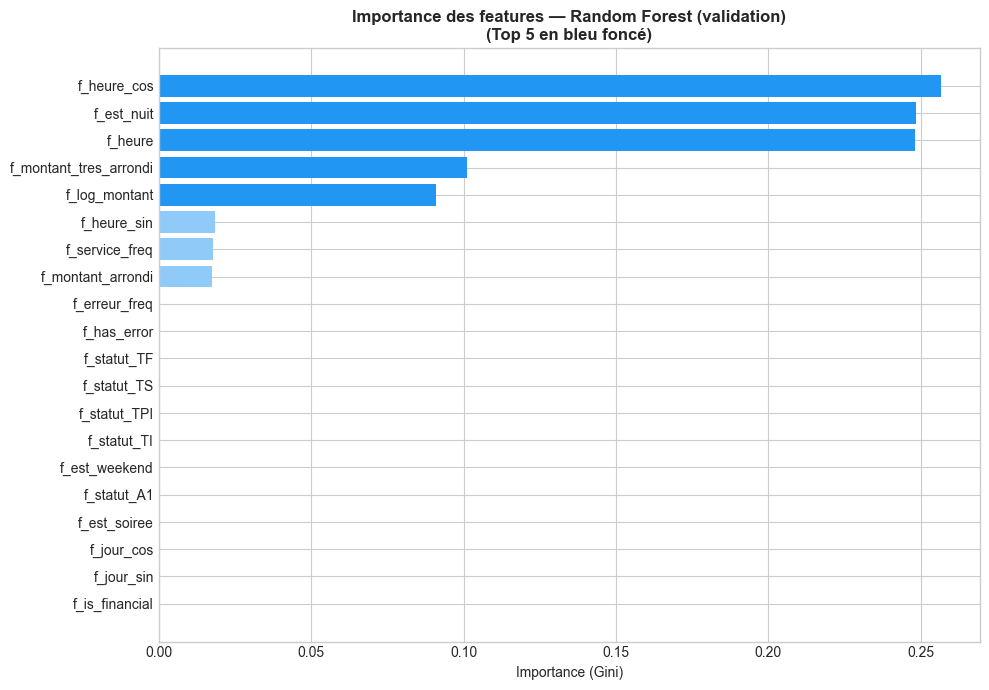


Top 10 features les plus importantes :
               feature  importance
           f_heure_cos        0.26
            f_est_nuit        0.25
               f_heure        0.25
f_montant_tres_arrondi        0.10
         f_log_montant        0.09
           f_heure_sin        0.02
        f_service_freq        0.02
     f_montant_arrondi        0.02
         f_erreur_freq        0.00
           f_has_error        0.00


In [25]:
# --- Importance des features ---
importances = pd.DataFrame({
    'feature'    : FEATURE_COLS,
    'importance' : rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(FEATURE_COLS) * 0.35)))
colors = ['#2196F3' if i < 5 else '#90CAF9' for i in range(len(importances))]
ax.barh(importances['feature'][::-1], importances['importance'][::-1], color=colors[::-1])
ax.set_title('Importance des features — Random Forest (validation)\n(Top 5 en bleu foncé)', fontweight='bold')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_RF.png', dpi=150)
plt.show()

print("\nTop 10 features les plus importantes :")
print(importances.head(10).to_string(index=False))

## 8. Matrice de corrélation des features

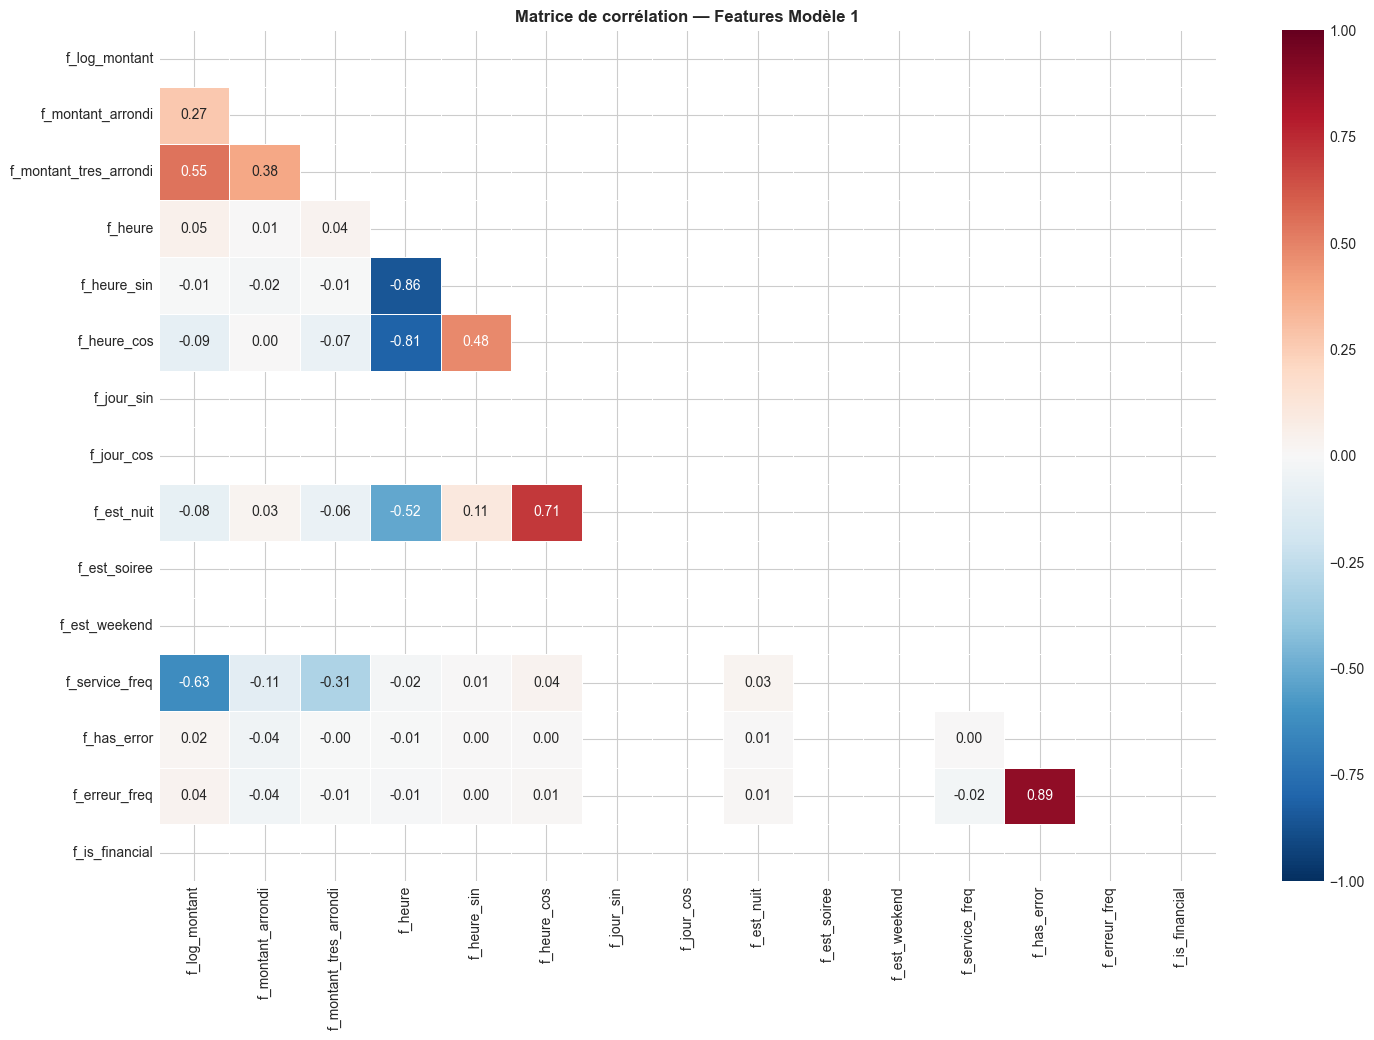


⚠️  Paires très corrélées (|r| > 0.8) — envisage d'en supprimer une :
  f_erreur_freq × f_has_error : 0.889
  f_heure_sin × f_heure : -0.858
  f_heure_cos × f_heure : -0.811


In [26]:
# Corrélation entre les features numériques
corr_cols = [c for c in FEATURE_COLS if df_feat[c].dtype in ['float64', 'int64', 'int32', 'float32']]
corr_matrix = df_feat[corr_cols].corr()

fig, ax = plt.subplots(figsize=(max(10, len(corr_cols)), max(8, len(corr_cols) * 0.7)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=len(corr_cols) <= 15,
    fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, ax=ax,
    linewidths=0.5
)
ax.set_title('Matrice de corrélation — Features Modèle 1', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_matrix.png', dpi=150)
plt.show()

# Paires très corrélées (à surveiller pour éviter la redondance)
corr_upper = corr_matrix.where(~mask)
paires_fortes = [
    (r, c, corr_upper.loc[r, c])
    for r in corr_upper.index
    for c in corr_upper.columns
    if abs(corr_upper.loc[r, c]) > 0.8
    and not pd.isna(corr_upper.loc[r, c])
]
if paires_fortes:
    print("\n⚠️  Paires très corrélées (|r| > 0.8) — envisage d'en supprimer une :")
    for r, c, v in sorted(paires_fortes, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {r} × {c} : {v:.3f}")
else:
    print("✅ Pas de corrélation excessive entre features.")

## 9. Stratégie de modélisation recommandée

In [27]:
print("=" * 65)
print("STRATÉGIE RECOMMANDÉE POUR LE MODÈLE 1")
print("=" * 65)

if HAS_LABELS:
    n_fraud = y.sum()
    taux    = y.mean() * 100
    print(f"\n✅ Labels réels disponibles : {n_fraud:,} fraudes ({taux:.3f}%)")
    print()
    print("→ ALGORITHME : LightGBM (supervisé)")
    print("   • class_weight='balanced' ou scale_pos_weight")
    print("   • Validation temporelle (TimeSeriesSplit) — PAS de KFold")
    print("   • Seuil de décision : optimiser F1 ou Precision@Recall sur la courbe P-R")
    print()
    print("→ MÉTRIQUE PRINCIPALE : ROC-AUC + Precision@Recall=0.5")
    print("   (éviter l'Accuracy qui est trompeuse sur données déséquilibrées)")
    print()
    print("→ NOTEBOOK SUIVANT : 02_M1_lightgbm_training.ipynb")
else:
    print("\n❌ Pas de labels réels détectés")
    print()
    print("→ ALGORITHME : Isolation Forest + calibration sur règles métier")
    print("   • contamination = 0.01 (1% de fraude supposée)")
    print("   • n_estimators = 300")
    print("   • Sortie : anomaly_score normalisé 0-100")
    print()
    print("   Alternative si vous obtenez des labels a posteriori :")
    print("   → Passer en LightGBM supervisé avec les features construites ici")
    print()
    print("→ VALIDATION : comparaison des alertes vs cas signalés manuellement")
    print()
    print("→ NOTEBOOK SUIVANT : 02_M1_isolation_forest.ipynb")

print()
print(f"→ FEATURES FINALES RETENUES ({len(FEATURE_COLS)}) :")
top5 = importances.head(5)['feature'].tolist() if 'importances' in dir() else FEATURE_COLS[:5]
print(f"   Top 5 : {top5}")
print(f"   Toutes : {FEATURE_COLS}")

STRATÉGIE RECOMMANDÉE POUR LE MODÈLE 1

❌ Pas de labels réels détectés

→ ALGORITHME : Isolation Forest + calibration sur règles métier
   • contamination = 0.01 (1% de fraude supposée)
   • n_estimators = 300
   • Sortie : anomaly_score normalisé 0-100

   Alternative si vous obtenez des labels a posteriori :
   → Passer en LightGBM supervisé avec les features construites ici

→ VALIDATION : comparaison des alertes vs cas signalés manuellement

→ NOTEBOOK SUIVANT : 02_M1_isolation_forest.ipynb

→ FEATURES FINALES RETENUES (20) :
   Top 5 : ['f_heure_cos', 'f_est_nuit', 'f_heure', 'f_montant_tres_arrondi', 'f_log_montant']
   Toutes : ['f_log_montant', 'f_montant_arrondi', 'f_montant_tres_arrondi', 'f_heure', 'f_heure_sin', 'f_heure_cos', 'f_jour_sin', 'f_jour_cos', 'f_est_nuit', 'f_est_soiree', 'f_est_weekend', 'f_statut_A1', 'f_statut_TF', 'f_statut_TI', 'f_statut_TPI', 'f_statut_TS', 'f_service_freq', 'f_has_error', 'f_erreur_freq', 'f_is_financial']


## 10. Export du dataset de features

In [28]:
# Colonnes à exporter pour le notebook 02
cols_export = FEATURE_COLS.copy()

if HAS_LABELS and LABEL_COL:
    cols_export += [LABEL_COL]
cols_export += ['PSEUDO_LABEL_FRAUDE']

# Identifiants utiles pour le dashboard
id_cols = ['TRANSFER_ID', COL_SENDER, COL_RECVR, COL_DATE, COL_MONTANT, COL_SERVICE, COL_STATUT]
id_cols = [c for c in id_cols if c in df_feat.columns]
cols_export = id_cols + [c for c in cols_export if c not in id_cols]

df_export = df_feat[cols_export].copy()

output_path = OUTPUT_DIR / 'M1_features_sample.parquet'
df_export.to_parquet(output_path, index=False)

taille_mb = output_path.stat().st_size / 1024**2
print(f"✅ Dataset exporté : {output_path}")
print(f"   {df_export.shape[0]:,} lignes × {df_export.shape[1]} colonnes")
print(f"   Taille : {taille_mb:.1f} Mo")
print()

# Résumé final
print("=" * 65)
print("RÉSUMÉ DE L'EXPLORATION M1")
print("=" * 65)
print(f"Lignes analysées   : {len(df):,}")
print(f"Features créées    : {len(FEATURE_COLS)}")
print(f"Bloc A (transac.)  : {len([c for c in FEATURE_COLS if any(k in c for k in ['montant','solde','ratio','delta'])])}")
print(f"Bloc B (temporel)  : {len([c for c in FEATURE_COLS if any(k in c for k in ['heure','jour','nuit','soiree','weekend'])])}")
print(f"Bloc C (comport.)  : {len([c for c in FEATURE_COLS if any(k in c for k in ['24h','7j','destinataires','taux_echec','services_distincts'])])}")
print(f"Bloc D (contexte)  : {len([c for c in FEATURE_COLS if any(k in c for k in ['statut','service','canal','erreur','ville','financial'])])}")
print(f"Labels disponibles : {'OUI → ' + str(LABEL_COL) if HAS_LABELS else 'NON → Isolation Forest'}")
print(f"Pseudo-labels      : {df_feat['PSEUDO_LABEL_FRAUDE'].sum():,} ({df_feat['PSEUDO_LABEL_FRAUDE'].mean()*100:.2f}%)")
print(f"\n→ Prêt pour : 02_M1_{'lightgbm_training' if HAS_LABELS else 'isolation_forest'}.ipynb")

✅ Dataset exporté : outputs\M1_fraude\M1_features_sample.parquet
   500,000 lignes × 26 colonnes
   Taille : 6.7 Mo

RÉSUMÉ DE L'EXPLORATION M1
Lignes analysées   : 500,000
Features créées    : 20
Bloc A (transac.)  : 3
Bloc B (temporel)  : 8
Bloc C (comport.)  : 0
Bloc D (contexte)  : 8
Labels disponibles : NON → Isolation Forest
Pseudo-labels      : 1,535 (0.31%)

→ Prêt pour : 02_M1_isolation_forest.ipynb
